# Retrieval Evaluation Playbook: FTS vs Vector vs Hybrid (LanceDB)

Этот ноутбук предназначен для оценки качества поиска в RAG-сервисе. Мы сравним три подхода:
- **Full Text Search (FTS / BM25)**
- **Vector Search (FastEmbed / BAAI/bge-small-en-v1.5)**
- **Hybrid Search (FTS + Vector)**

In [1]:
import hashlib
import json
import os
import re
import time
from dotenv import load_dotenv
from fastembed import TextEmbedding
import httpx
import lancedb
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

load_dotenv(override=True)

True

## 1. Подключение к LanceDB S3/MinIO и подготовка FTS

In [2]:
TABLE_NAME = os.getenv("TABLE_NAME", "pdf_vectors")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "BAAI/bge-small-en-v1.5")
S3_BUCKET_NAME = os.getenv("S3_BUCKET_NAME", "")
S3_ACCESS_KEY = os.getenv("S3_ACCESS_KEY", "")
S3_SECRET_KEY = os.getenv("S3_SECRET_KEY", "")
S3_ENDPOINT_URL = os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net")
AWS_REGION = os.getenv("AWS_REGION", "ru-central1")

OLLAMA_URL = os.getenv("OLLAMA_URL", "http://apps.akimovp.ru/api/generate")
LLM_MODEL_NAME = os.getenv("LLM_MODEL_NAME", "qwen2.5:1.5b")

OLLAMA_MODEL = LLM_MODEL_NAME

s3_uri = f"s3://{S3_BUCKET_NAME}/lancedb"
storage_options = {
    "aws_access_key_id": S3_ACCESS_KEY,
    "aws_secret_access_key": S3_SECRET_KEY,
    "aws_region": AWS_REGION,
    "aws_endpoint": S3_ENDPOINT_URL,
    "allow_http": "true" if S3_ENDPOINT_URL.startswith("http://") else "false",
}

db = lancedb.connect(s3_uri, storage_options=storage_options)
table = db.open_table(TABLE_NAME)

print(f"Connected to table '{TABLE_NAME}'. Total rows: {table.count_rows()}")

# Создаем полнотекстовый индекс для реализации FTS и Hybrid поиска
try:
    table.create_fts_index("text", replace=True)
    print("FTS index successfully created/updated.")
except Exception as e:
    print(f"FTS Index status/warning: {e}")

embedder = TextEmbedding(model_name=EMBEDDING_MODEL)

Connected to table 'pdf_vectors'. Total rows: 1117


/tmp/ipykernel_8163/3561264231.py:30: DeprecatedWarning: create_fts_index is deprecated as of 0.25.0. Use create_index() with config=FTS() instead.
  table.create_fts_index("text", replace=True)


FTS index successfully created/updated.


## 2. Генерация Ground Truth датасета через локальную Ollama (Qwen2.5)

Берем выборку чанков из LanceDB и генерируем синтетические вопросы с помощью локально развернутого сервиса Ollama.

In [3]:
raw_docs = table.search().limit(200).to_list()
documents = []

for d in raw_docs:
    # d может быть словарем или pyarrow / lancedb объектом
    text = d.get("text", "") if isinstance(d, dict) else getattr(d, "text", "")
    meta = d.get("metadata", {}) if isinstance(d, dict) else getattr(d, "metadata", {})
    
    # Если metadata пришла в виде JSON-строки, парсим её в dict
    if isinstance(meta, str):
        try:
            meta = json.loads(meta)
        except Exception:
            meta = {}
    elif not isinstance(meta, dict):
        meta = {}

    # Безопасно извлекаем doc_id
    doc_id = meta.get("chunk_id") or meta.get("id") or hashlib.md5(text.encode()).hexdigest()
    
    documents.append({
        "doc_id": str(doc_id),
        "text": text,
        "metadata": meta
    })

prompt_template = """
You are an expert building an evaluation dataset for a RAG system.
Formulate 3 distinct and specific questions that can be directly answered by the text chunk below.
Do not invent facts not present in the chunk.

Text chunk:
{text}

Provide the output STRICTLY as a valid JSON object with key 'questions':
{{"questions": ["question1", "question2", "question3"]}}
""".strip()

def generate_questions_ollama(text: str) -> dict:
    prompt = prompt_template.format(text=text)
    payload = {
        "model": LLM_MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "format": "json",
        "options": {
            "temperature": 0.1,
            "num_predict": 200,
            "num_thread": 4
        }
    }
    with httpx.Client(timeout=60.0) as client:
        response = client.post(OLLAMA_URL, json=payload)
        response.raise_for_status()
        res_json = response.json()
        raw_resp = res_json.get("response", "{}")
        return json.loads(raw_resp) if isinstance(raw_resp, str) else raw_resp

ground_truth_records = []
print("Generating questions for evaluation via Ollama...")

for doc in tqdm(documents[:50]):
    try:
        res = generate_questions_ollama(doc["text"])
        questions = res.get("questions", [])
        if isinstance(questions, str):
            questions = [q.strip() for q in questions.split("\n") if q.strip()]
        
        for q in questions:
            if q and isinstance(q, str):
                ground_truth_records.append({
                    "question": q,
                    "target_id": doc["doc_id"],
                    "target_metadata": doc["metadata"],
                    "target_text": doc["text"]
                })
    except Exception as e:
        print(f"Error generating for doc {doc['doc_id']}: {e}")

df_gt = pd.DataFrame(ground_truth_records)
os.makedirs("../data", exist_ok=True)
df_gt.to_csv("../data/ground_truth_eval.csv", index=False)
print(f"Created {len(df_gt)} ground truth evaluation samples.")
df_gt.head()

Generating questions for evaluation via Ollama...


  0%|          | 0/50 [00:00<?, ?it/s]

Created 150 ground truth evaluation samples.


,question,target_id,target_metadata,target_text
0,What is the URL of the website?,dd099b11e9146eaf98842da47c422620,{},www.urdukutabkhanapk.blogspot.com A Little His...
1,Who is the author of the book 'A Little Histor...,dd099b11e9146eaf98842da47c422620,{},www.urdukutabkhanapk.blogspot.com A Little His...
2,Who is the author of the poem 'I Have a Dream'?,dd099b11e9146eaf98842da47c422620,{},www.urdukutabkhanapk.blogspot.com A Little His...
3,What is the copyright holder of the book?,546863f3f77cf03123e45c096403f8fc,{},"or, New Y ork, NY . © 1963 Dr. Martin Luther K..."
4,When was the book first published?,546863f3f77cf03123e45c096403f8fc,{},"or, New Y ork, NY . © 1963 Dr. Martin Luther K..."


## 3. Определение методов поиска

In [4]:
def search_vector(query: str, k: int = 5):
    query_vector = next(embedder.embed([query])).tolist()
    results = table.search(query_vector, query_type="vector").select(["text", "metadata"]).limit(k).to_list()
    return results

def search_fts(query: str, k: int = 5):
    results = table.search(query, query_type="fts").select(["text", "metadata"]).limit(k).to_list()
    return results

def search_hybrid(query: str, k: int = 5):
    query_vector = next(embedder.embed([query])).tolist()
    try:
        results = (
            table.search(query_type="hybrid")
            .vector(query_vector)
            .text(query)
            .select(["text", "metadata"])
            .limit(k)
            .to_list()
        )
    except Exception:
        # Fallback на векторный поиск при возникновении ошибок API
        results = table.search(query_vector).select(["text", "metadata"]).limit(k).to_list()
    return results

## 4. Метрики качества (Hit Rate & MRR)

In [5]:
def extract_doc_id(res_dict: dict) -> str:
    text = res_dict.get("text", "") if isinstance(res_dict, dict) else getattr(res_dict, "text", "")
    meta = res_dict.get("metadata", {}) if isinstance(res_dict, dict) else getattr(res_dict, "metadata", {})
    
    if isinstance(meta, str):
        try:
            meta = json.loads(meta)
        except Exception:
            meta = {}
    elif not isinstance(meta, dict):
        meta = {}

    doc_id = meta.get("chunk_id") or meta.get("id") or hashlib.md5(text.encode()).hexdigest()
    return str(doc_id)

def evaluate_search(search_fn, gt_df: pd.DataFrame, k: int = 5):
    hit_count = 0
    mrr_sum = 0.0
    latencies = []

    for _, row in tqdm(gt_df.iterrows(), total=len(gt_df)):
        question = row["question"]
        target_id = str(row["target_id"])
        
        start_time = time.perf_counter()
        results = search_fn(question, k=k)
        latencies.append(time.perf_counter() - start_time)
        
        retrieved_ids = [extract_doc_id(r) for r in results]
        
        if target_id in retrieved_ids:
            hit_count += 1
            rank = retrieved_ids.index(target_id) + 1
            mrr_sum += 1.0 / rank

    hit_rate = hit_count / len(gt_df) if len(gt_df) > 0 else 0
    mrr = mrr_sum / len(gt_df) if len(gt_df) > 0 else 0
    avg_latency = (sum(latencies) / len(latencies)) * 1000 if len(latencies) > 0 else 0
    
    return {
        "hit_rate": round(hit_rate, 4),
        "mrr": round(mrr, 4),
        "avg_latency_ms": round(avg_latency, 2)
    }

## 5. Запуск бенчмарка и сравнение результатов

In [6]:
TOP_K = 5

print("Evaluating Vector Search...")
metrics_vector = evaluate_search(search_vector, df_gt, k=TOP_K)

print("Evaluating Full-Text Search (FTS)...")
metrics_fts = evaluate_search(search_fts, df_gt, k=TOP_K)

print("Evaluating Hybrid Search...")
metrics_hybrid = evaluate_search(search_hybrid, df_gt, k=TOP_K)

df_metrics = pd.DataFrame([
    {"Method": "Vector Search", **metrics_vector},
    {"Method": "Full-Text Search (FTS)", **metrics_fts},
    {"Method": "Hybrid Search", **metrics_hybrid}
])

df_metrics

Evaluating Vector Search...


  0%|          | 0/150 [00:00<?, ?it/s]

[2026-08-27T17:34:52Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_distance`.  Currently the `_distance` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:34:58Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_distance`.  Currently the `_distance` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:35:02Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_distance`.  Currently the `_distance` column will be included.  In the future it will not.  Call `disable_scoring_

Evaluating Full-Text Search (FTS)...


  0%|          | 0/150 [00:00<?, ?it/s]

[2026-08-27T17:44:08Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_score`.  Currently the `_score` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:44:09Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_score`.  Currently the `_score` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:44:12Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_score`.  Currently the `_score` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to

Evaluating Hybrid Search...


  0%|          | 0/150 [00:00<?, ?it/s]

[2026-08-27T17:45:49Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_score`.  Currently the `_score` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:45:49Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_distance`.  Currently the `_distance` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning
[2026-08-27T17:45:53Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_score`.  Currently the `_score` column will be included.  In the future it will not.  Call `disable_scoring_autoprojecti

,Method,hit_rate,mrr,avg_latency_ms
0,Vector Search,0.8800,0.7200,3708.94
1,Full-Text Search (FTS),0.8200,0.7350,665.01
2,Hybrid Search,0.8867,0.7662,3148.75


## 6. Визуализация результатов

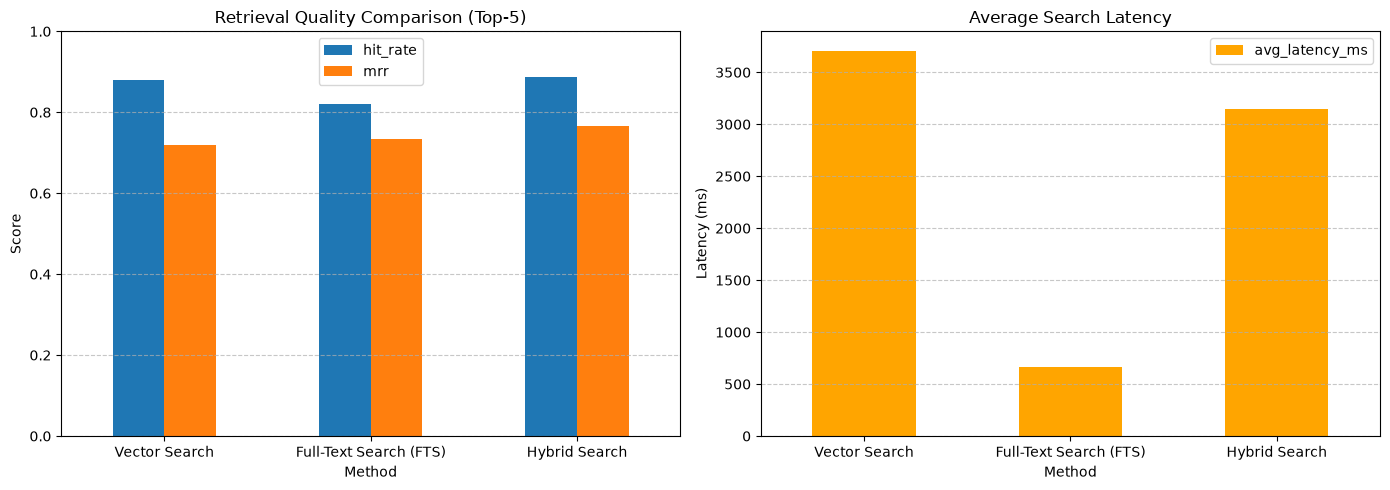

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# График Hit Rate и MRR
df_metrics.plot(x="Method", y=["hit_rate", "mrr"], kind="bar", ax=ax[0], rot=0)
ax[0].set_title(f"Retrieval Quality Comparison (Top-{TOP_K})")
ax[0].set_ylabel("Score")
ax[0].set_ylim(0, 1.0)
ax[0].grid(axis="y", linestyle="--", alpha=0.7)

# График Latency
df_metrics.plot(x="Method", y="avg_latency_ms", kind="bar", color="orange", ax=ax[1], rot=0)
ax[1].set_title("Average Search Latency")
ax[1].set_ylabel("Latency (ms)")
ax[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()